In [ ]:
# Exploratory Data Analysis on Retail Sales Data

## Oasis Infobyte Data Analytics Internship

### Objective
Analyze retail sales transactions to identify customer purchasing patterns, product performance, and sales trends using data visualization and statistical techniques.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [21]:
df = pd.read_csv("retail_sales_dataset.csv")

In [22]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [23]:
df.shape

(1000, 9)

In [24]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


## Data Understanding

The dataset contains 1000 retail transactions and 9 attributes. It includes customer demographics, product categories, transaction quantities, pricing information, and total sales amounts.

In [26]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [27]:
df.duplicated().sum()

np.int64(0)

In [28]:
df['Date'] = pd.to_datetime(df['Date'])

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


## Data Cleaning

The dataset was checked for missing values and duplicate records. No missing values were found. The Date column was converted to datetime format to enable time-series analysis.

In [30]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [31]:
total_revenue = df['Total Amount'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 456000


In [32]:
avg_transaction = df['Total Amount'].mean()

print("Average Transaction Value:", round(avg_transaction,2))

Average Transaction Value: 456.0


In [33]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()

category_sales

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

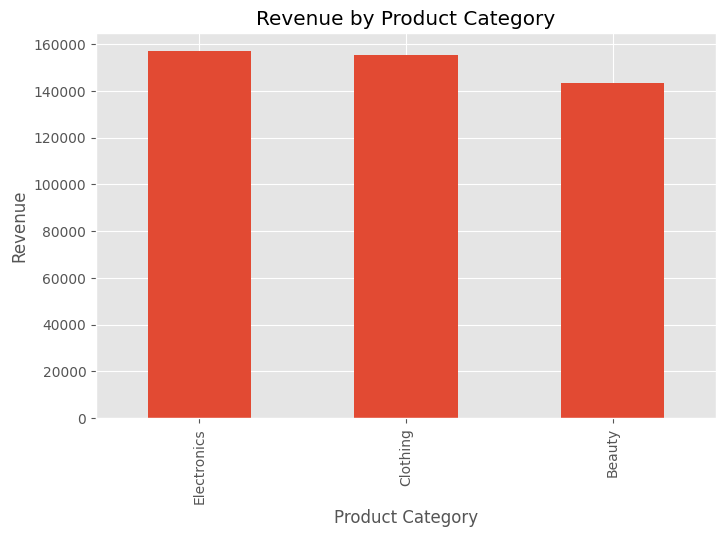

In [34]:
plt.figure(figsize=(8,5))

category_sales.sort_values(ascending=False).plot(kind='bar')

plt.title('Revenue by Product Category')
plt.ylabel('Revenue')
plt.xlabel('Product Category')

plt.show()

In [46]:
gender_sales = df.groupby('Gender')['Total Amount'].sum()

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

### Gender-Based Sales Analysis

Female customers generated a total revenue of 232,840, while male customers generated 223,160.

This indicates that female customers contributed slightly more to overall sales, suggesting a marginally higher purchasing activity compared to male customers.

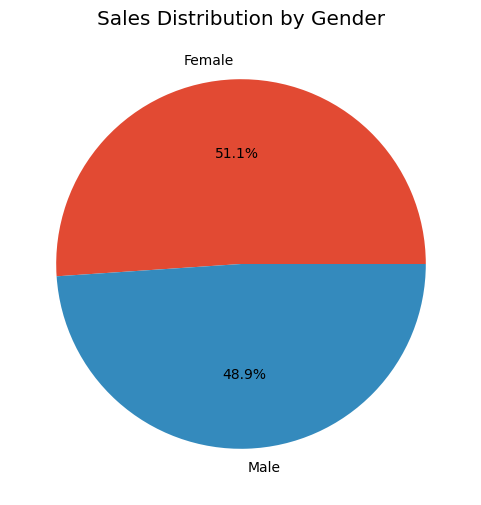

In [36]:
plt.figure(figsize=(6,6))

gender_sales.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Sales Distribution by Gender')
plt.ylabel('')

plt.show()

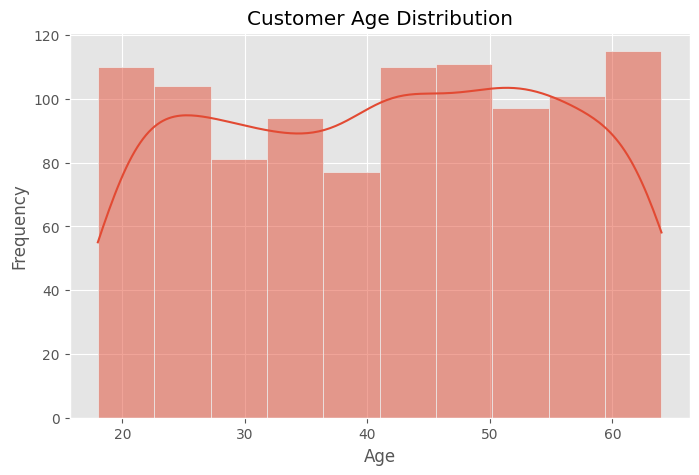

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=10,
    kde=True
)

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

In [38]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0,18,25,35,45,55,100],
    labels=['<18','18-25','26-35','36-45','46-55','55+']
)

In [39]:
age_sales = df.groupby('Age Group')['Total Amount'].sum()

age_sales

Age Group
<18       11215
18-25     73335
26-35     98480
36-45     91870
46-55    100690
55+       80410
Name: Total Amount, dtype: int64

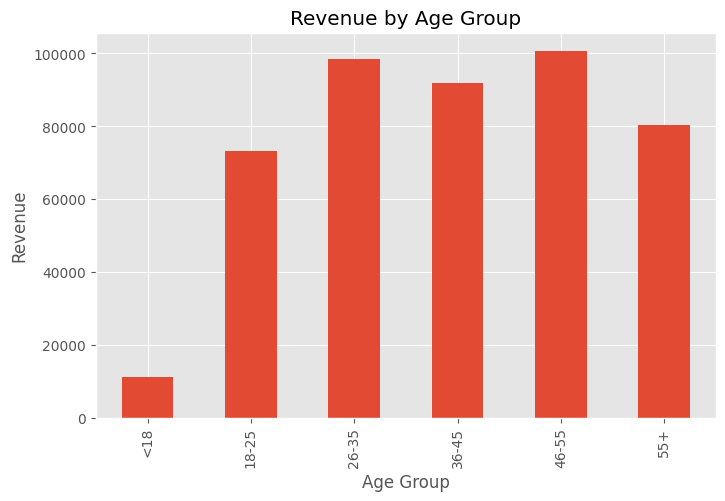

In [40]:
plt.figure(figsize=(8,5))

age_sales.plot(kind='bar')

plt.title('Revenue by Age Group')
plt.ylabel('Revenue')
plt.xlabel('Age Group')

plt.show()

In [41]:
df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales

Month
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Total Amount, dtype: int64

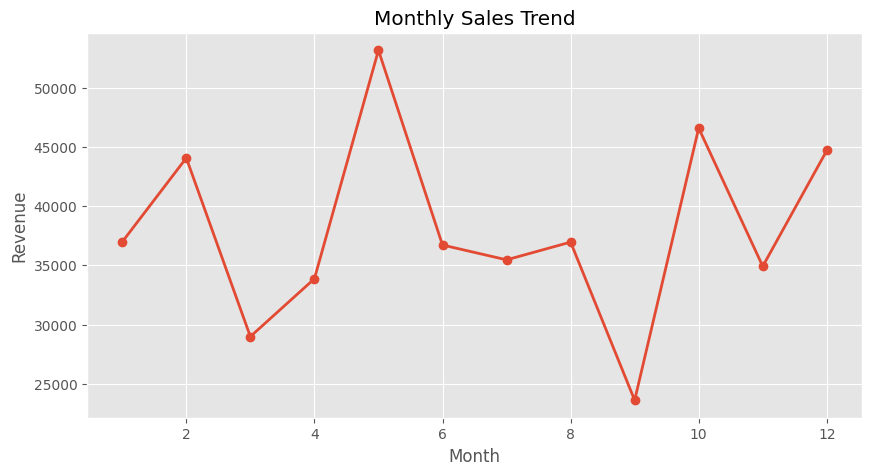

In [42]:
plt.figure(figsize=(10,5))

monthly_sales.plot(
    marker='o',
    linewidth=2
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.grid(True)

plt.show()

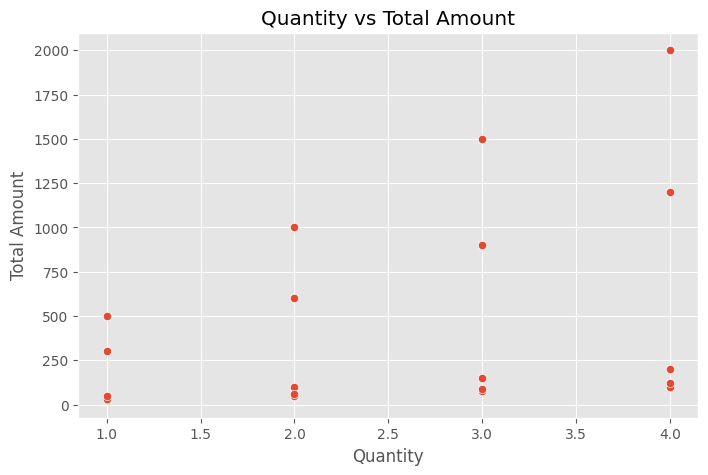

In [43]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='Total Amount'
)

plt.title('Quantity vs Total Amount')

plt.show()

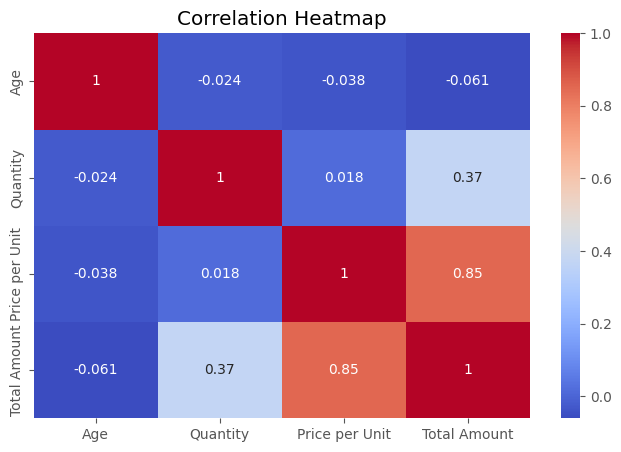

In [44]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Age','Quantity','Price per Unit','Total Amount']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()


## Key Insights

1. Female customers generated slightly higher revenue (232,840) than male customers (223,160).

2. Product category analysis revealed the highest-performing category in terms of revenue generation.

3. Customer spending patterns varied across different age groups.

4. Monthly sales trends showed fluctuations in customer purchasing behavior throughout the year.

5. Quantity purchased exhibited a positive relationship with total transaction amount.

   
## Recommendations

1. Focus marketing campaigns on the highest-performing product categories to maximize revenue.

2. Develop targeted promotional strategies for customer segments that contribute the most sales.

3. Optimize inventory management during peak sales periods to prevent stock shortages.

4. Introduce discounts and promotional offers for lower-performing categories to improve sales performance.

5. Utilize customer demographic insights to create personalized marketing initiatives and enhance customer engagement.


## Conclusion

This project analyzed retail sales transaction data using Exploratory Data Analysis (EDA) techniques. The analysis provided valuable insights into customer demographics, purchasing behavior, product category performance, and sales trends. The findings can support data-driven decision-making, helping businesses improve marketing strategies, inventory planning, and overall sales performance.